<a href="https://colab.research.google.com/github/Rame395/Machine-Learning/blob/main/Feature_Scaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Feature Scaling**

Feature Engineering is the process of crating, transforming or selecting important features from raw data to improve model performance

1. Absolute Maximum Scaling

   Absolute Maximum Scaling is a feature scaling method where each value is divided by the maximum absolute value of that feature. This transformation rescales the data so that values fall within the range of -1 to 1.

  Scaling Formula:
     **X**scaled = **X**i / max(|x|)

**Why we use feature Scaling?**

  Imagine trying to compare a person's age (0–100) to their annual salary (Rs0–Rs500,000). If you feed these raw numbers into a machine learning algorithm, it will likely assume the salary is 5,000 times more important than the age just because the numbers are bigger.

Import Libraries and Dataset

In [45]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv("/content/data.csv")
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [ ]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


Select only the numerical feature that actually need scaling

In [36]:
df2 = df.copy()

In [ ]:
df2.shape

(4600, 18)

In [37]:
df2 = df2.iloc[ : , 2:14]

In [38]:
df2

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005
1,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0
2,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0
3,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0
4,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992
...,...,...,...,...,...,...,...,...,...,...,...,...
4595,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979
4596,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009
4597,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0
4598,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0


Seperating Feature X and y

In [39]:
X = df2
y= df['price']

 Train-Test Split

 split before scaling to prevent data leakage!

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Initialize and Apply the Scaler

We use StandardScaler because real estate data often has large variance

In [41]:
Scaler = StandardScaler()

Fit on training data and transform both

In [42]:
X_train_scaled = Scaler.fit_transform(X_train)
X_test_scaled = Scaler.transform(X_test)

In [43]:
x_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

In [44]:
x_train_scaled_df.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
0,0.670520,0.436902,0.660971,0.870054,0.910403,-0.085972,-0.306194,0.808830,1.105179,-0.679582,0.626721,-0.822446
1,0.670520,1.074918,1.652011,0.406802,0.910403,-0.085972,-0.306194,-0.672013,2.211185,-0.679582,0.693925,-0.822446
2,0.670520,0.436902,0.702699,-0.097288,0.910403,-0.085972,-0.306194,-0.672013,1.151748,-0.679582,0.391508,-0.822446
3,0.670520,2.031941,1.975402,-0.106289,0.910403,-0.085972,-0.306194,-0.672013,2.572092,-0.679582,1.197954,-0.822446
4,-0.430066,-0.201114,-0.142292,-0.213165,0.910403,-0.085972,-0.306194,-0.672013,0.208732,-0.679582,-1.826218,1.206786


Visualizing Outliners

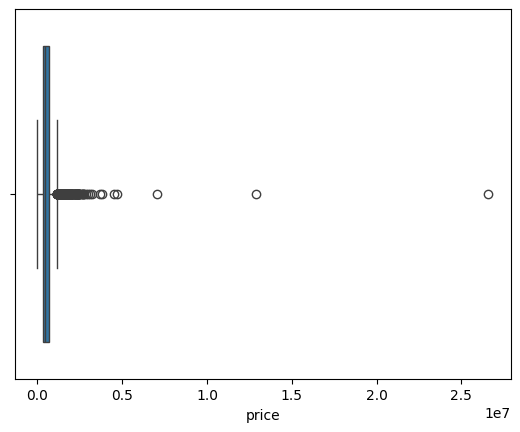

In [56]:

sns.boxplot(data=y, orient='h')
plt.show()
